In [1]:
import numpy as np                                                              
import pandas as pd                                                            
import seaborn as sns                                                           
import matplotlib.pyplot as plt  

In [2]:
df = pd.read_csv("NBA_players_data.csv")

In [3]:
df.shape

(12844, 22)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12844 entries, 0 to 12843
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         12844 non-null  int64  
 1   player_name        12844 non-null  object 
 2   team_abbreviation  12844 non-null  object 
 3   age                12844 non-null  float64
 4   player_height      12844 non-null  float64
 5   player_weight      12844 non-null  float64
 6   college            10990 non-null  object 
 7   country            12844 non-null  object 
 8   draft_year         12844 non-null  object 
 9   draft_round        12844 non-null  object 
 10  draft_number       12844 non-null  object 
 11  gp                 12844 non-null  int64  
 12  pts                12844 non-null  float64
 13  reb                12844 non-null  float64
 14  ast                12844 non-null  float64
 15  net_rating         12844 non-null  float64
 16  oreb_pct           128

In [5]:
df.isnull().sum()

Unnamed: 0              0
player_name             0
team_abbreviation       0
age                     0
player_height           0
player_weight           0
college              1854
country                 0
draft_year              0
draft_round             0
draft_number            0
gp                      0
pts                     0
reb                     0
ast                     0
net_rating              0
oreb_pct                0
dreb_pct                0
usg_pct                 0
ts_pct                  0
ast_pct                 0
season                  0
dtype: int64

## College the only column that has Null Values

In [6]:
df.head()

,Unnamed: 0,player_name,team_abbreviation,age,player_height,player_weight,college,country,draft_year,draft_round,...,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct,season
0,0,Randy Livingston,HOU,22.0,193.04,94.800728,Louisiana State,USA,1996,2,...,3.9,1.5,2.4,0.3,0.042,0.071,0.169,0.487,0.248,1996-97
1,1,Gaylon Nickerson,WAS,28.0,190.50,86.182480,Northwestern Oklahoma,USA,1994,2,...,3.8,1.3,0.3,8.9,0.030,0.111,0.174,0.497,0.043,1996-97
2,2,George Lynch,VAN,26.0,203.20,103.418976,North Carolina,USA,1993,1,...,8.3,6.4,1.9,-8.2,0.106,0.185,0.175,0.512,0.125,1996-97
3,3,George McCloud,LAL,30.0,203.20,102.058200,Florida State,USA,1989,1,...,10.2,2.8,1.7,-2.7,0.027,0.111,0.206,0.527,0.125,1996-97
4,4,George Zidek,DEN,23.0,213.36,119.748288,UCLA,USA,1995,1,...,2.8,1.7,0.3,-14.1,0.102,0.169,0.195,0.500,0.064,1996-97


# The Data

## Explanation of the columns:

Unnamed - A placeholder column for index numbers, often used to retain the original index during data imports.

player_name - The full name of the basketball player.

team_abbreviation - Abbreviation of the player's team name (e.g., HOU for Houston Rockets).

age - The age of the player during the season.

player_height - The height of the player (CM) 

player_weight - The weight of the player (KG).

college - The name of the college the player attended before joining the professional league.

country - The player's country of origin or representation.

draft_year - The year the player was drafted into the league.

draft_round - The round of the draft in which the player was selected. 

draft_number Indicating the specific pick number.

gp The total number of games played by the player.

net_rating - The player's net rating, calculated as the difference between offensive and defensive ratings.

oreb_pct - Offensive rebound percentage 

dreb_pct - Defensive rebound percentage 

reb - Average rebounds per game.

usg_pct - Usage percentage; estimates the percentage of team plays used by the player while on the court.

ts_pct - True shooting percentage; measures shooting efficiency considering field goals, 3-point field goals, and free throws.

ast_pct - Assist percentage  

ast - Average assists per game by the player.

pts - Average points scored per game by the player during the season.

season - The NBA season in which the statistics were recorded (e.g., 1996-97).

In [7]:
df.dtypes

Unnamed: 0             int64
player_name           object
team_abbreviation     object
age                  float64
player_height        float64
player_weight        float64
college               object
country               object
draft_year            object
draft_round           object
draft_number          object
gp                     int64
pts                  float64
reb                  float64
ast                  float64
net_rating           float64
oreb_pct             float64
dreb_pct             float64
usg_pct              float64
ts_pct               float64
ast_pct              float64
season                object
dtype: object

In [8]:
df['draft_year'] = pd.to_numeric(df['draft_year'], errors='coerce').fillna(0).astype(int)
df['draft_round'] = pd.to_numeric(df['draft_round'], errors='coerce').fillna(0).astype(int)
df['draft_number'] = pd.to_numeric(df['draft_number'], errors='coerce').fillna(0).astype(int)

In [9]:
df.dtypes

Unnamed: 0             int64
player_name           object
team_abbreviation     object
age                  float64
player_height        float64
player_weight        float64
college               object
country               object
draft_year             int64
draft_round            int64
draft_number           int64
gp                     int64
pts                  float64
reb                  float64
ast                  float64
net_rating           float64
oreb_pct             float64
dreb_pct             float64
usg_pct              float64
ts_pct               float64
ast_pct              float64
season                object
dtype: object

In [10]:
print('Number of player' ,len(df['player_name'].unique()))

Number of player 2551


In [11]:
print("Number of season",len(df['season'].unique()))

Number of season 27


In [12]:
copy_of_df = df.copy()

In [13]:
df['college'].value_counts()

college
Kentucky             447
Duke                 410
North Carolina       355
UCLA                 318
Arizona              293
                    ... 
Arizona St.            1
Stephen F. Austin      1
San Francisco          1
John A. Logan          1
Buffalo                1
Name: count, Length: 356, dtype: int64

In [14]:
len(df['college'].value_counts())

356

In [15]:
df['country'].value_counts()

country
USA                    10721
Canada                   205
France                   190
Australia                100
Spain                     93
                       ...  
Sudan (UK)                 1
Trinidad and Tobago        1
Ghana                      1
Denmark                    1
Colombia                   1
Name: count, Length: 82, dtype: int64

In [16]:
len(df['country'].value_counts())

82

In [17]:
df['team_abbreviation'].value_counts()

team_abbreviation
CLE    450
TOR    446
MIA    443
DAL    443
LAC    442
WAS    442
ATL    439
PHI    438
SAS    434
HOU    433
LAL    429
IND    428
POR    428
DEN    428
ORL    428
MIL    427
NYK    426
GSW    426
BOS    425
CHI    423
DET    419
SAC    418
MIN    417
UTA    417
PHX    415
MEM    370
CHA    305
NJN    257
OKC    255
BKN    200
SEA    182
NOP    175
NOH    143
CHH     89
VAN     72
NOK     32
Name: count, dtype: int64

In [18]:
len(df['team_abbreviation'].value_counts())

36

In [19]:
df['season'].value_counts()

season
2021-22    605
2017-18    540
2020-21    540
2022-23    539
2018-19    530
2019-20    529
2014-15    492
2016-17    486
2013-14    482
2011-12    478
2015-16    476
2012-13    469
2004-05    464
2006-07    458
2005-06    458
2010-11    452
2007-08    451
2008-09    445
2003-04    442
2009-10    442
2000-01    441
1996-97    441
2001-02    440
1997-98    439
1998-99    439
1999-00    438
2002-03    428
Name: count, dtype: int64

In [20]:
len(df['season'].value_counts())

27

In [21]:
df.drop([
    'Unnamed: 0', 'player_name', 'college', 'country',
    'season', 'team_abbreviation',],axis=1,inplace=True)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12844 entries, 0 to 12843
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            12844 non-null  float64
 1   player_height  12844 non-null  float64
 2   player_weight  12844 non-null  float64
 3   draft_year     12844 non-null  int64  
 4   draft_round    12844 non-null  int64  
 5   draft_number   12844 non-null  int64  
 6   gp             12844 non-null  int64  
 7   pts            12844 non-null  float64
 8   reb            12844 non-null  float64
 9   ast            12844 non-null  float64
 10  net_rating     12844 non-null  float64
 11  oreb_pct       12844 non-null  float64
 12  dreb_pct       12844 non-null  float64
 13  usg_pct        12844 non-null  float64
 14  ts_pct         12844 non-null  float64
 15  ast_pct        12844 non-null  float64
dtypes: float64(12), int64(4)
memory usage: 1.6 MB


In [23]:
df_non_categorical = df.copy()

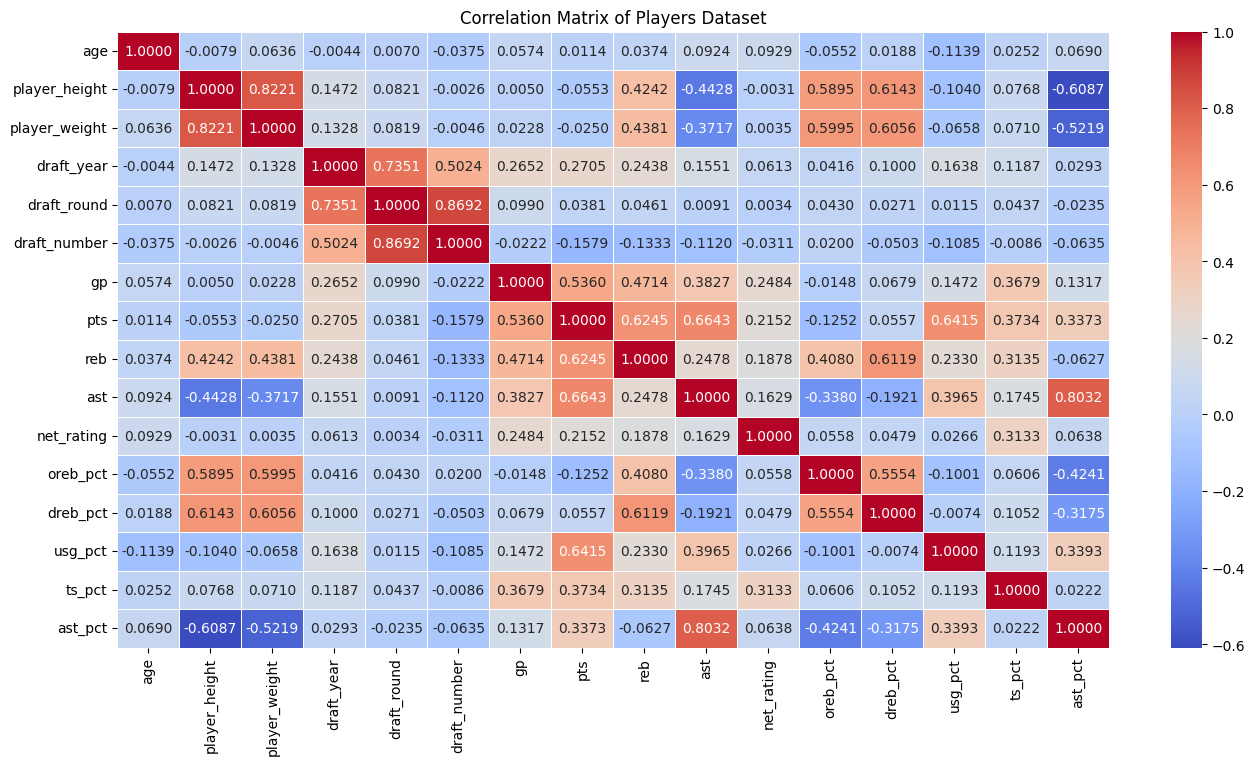

In [24]:
correlation_matrix = df.select_dtypes(exclude=['object']).corr()
plt.figure(figsize=(16, 8))  
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.4f', linewidths=0.5)  
plt.title('Correlation Matrix of Players Dataset') 
plt.show()  

In [25]:
df.describe()

,age,player_height,player_weight,draft_year,draft_round,draft_number,gp,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct
count,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000
mean,27.045313,200.555097,100.263279,1636.115151,1.059172,17.774914,51.154158,8.212582,3.558486,1.824681,-2.226339,0.054073,0.140646,0.184641,0.513138,0.131595
std,4.339211,9.111090,12.426628,775.928390,0.683223,16.803276,25.084904,6.016573,2.477885,1.800840,12.665124,0.043335,0.062513,0.053545,0.101724,0.094172
min,18.000000,160.020000,60.327736,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,-250.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,24.000000,193.040000,90.718400,1991.000000,1.000000,3.000000,31.000000,3.600000,1.800000,0.600000,-6.400000,0.021000,0.096000,0.149000,0.482000,0.066000
50%,26.000000,200.660000,99.790240,2001.000000,1.000000,14.000000,57.000000,6.700000,3.000000,1.200000,-1.300000,0.040000,0.130500,0.181000,0.525000,0.103000
75%,30.000000,208.280000,108.862080,2009.000000,1.000000,29.000000,73.000000,11.500000,4.700000,2.400000,3.200000,0.083000,0.179000,0.217000,0.563000,0.179000
max,44.000000,231.140000,163.293120,2022.000000,8.000000,165.000000,85.000000,36.100000,16.300000,11.700000,300.000000,1.000000,1.000000,1.000000,1.500000,1.000000


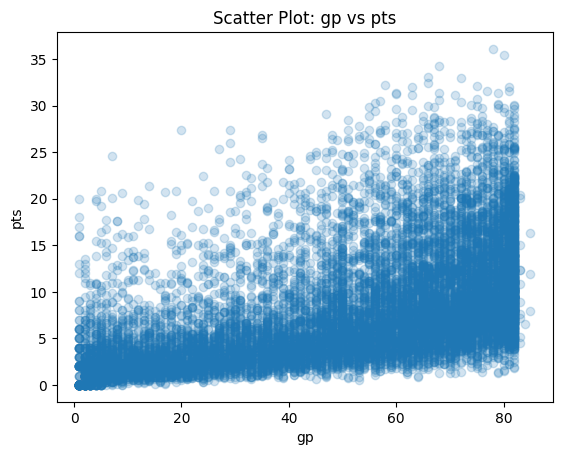

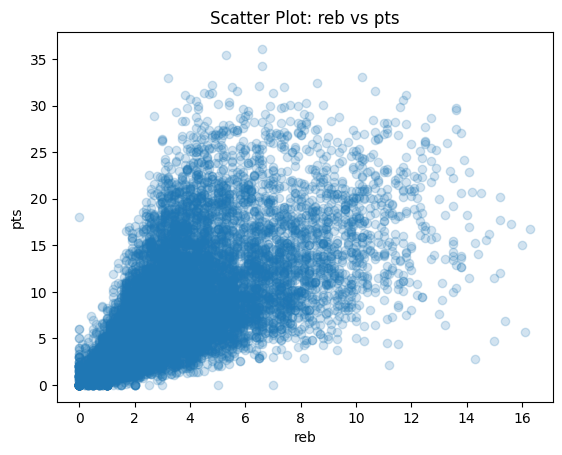

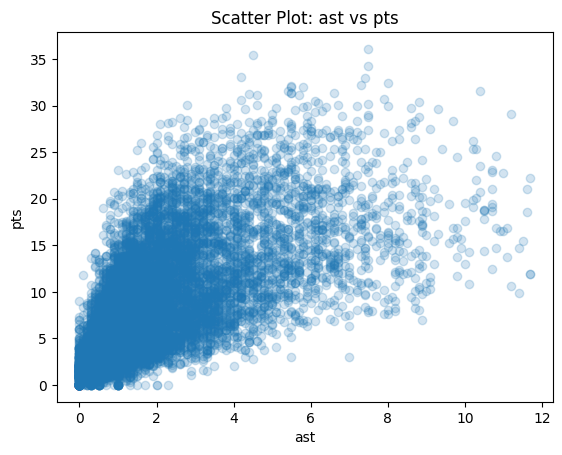

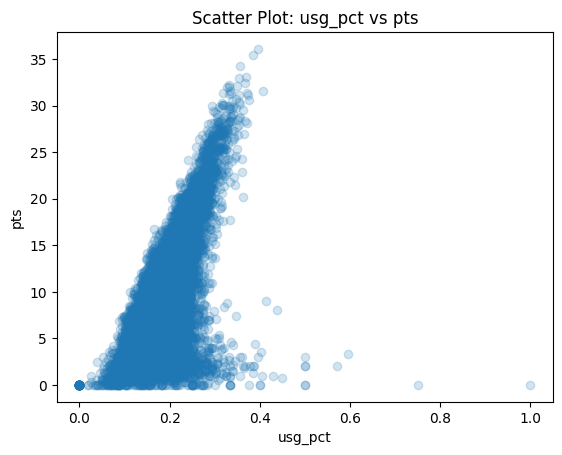

In [26]:
import matplotlib.pyplot as plt

high_corr_vars = ['gp', 'reb', 'ast', 'usg_pct']

for col in high_corr_vars:
    plt.figure()
    plt.scatter(df[col], df['pts'], alpha=.2)
    plt.xlabel(col)
    plt.ylabel('pts')
    plt.title(f'Scatter Plot: {col} vs pts')
    plt.show()

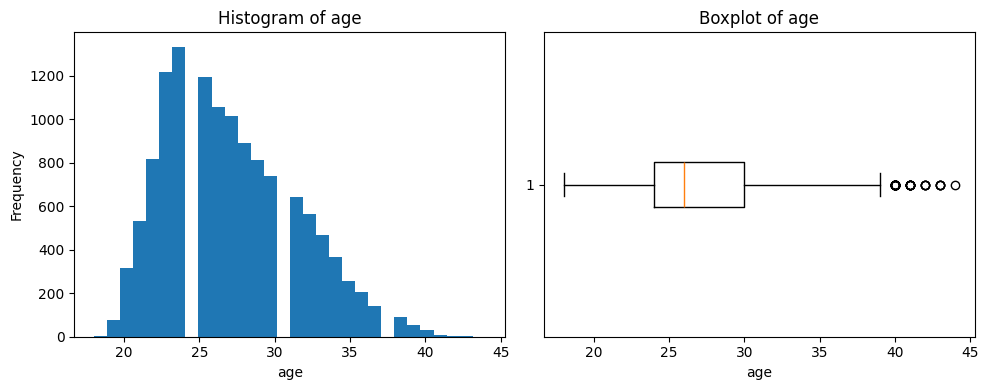

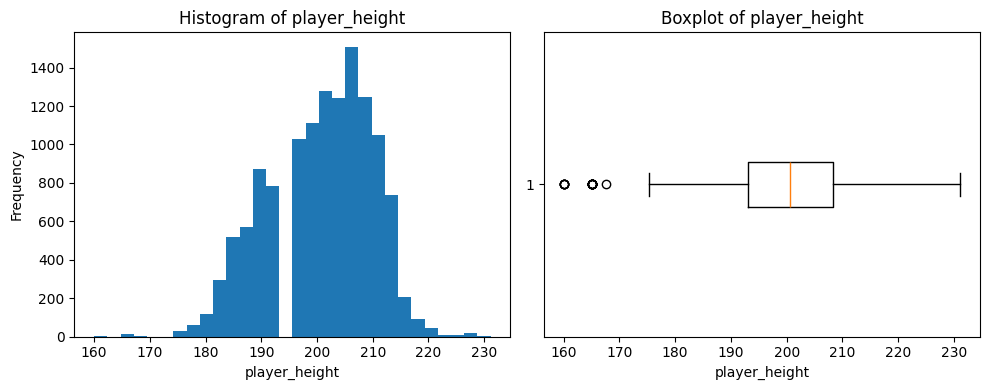

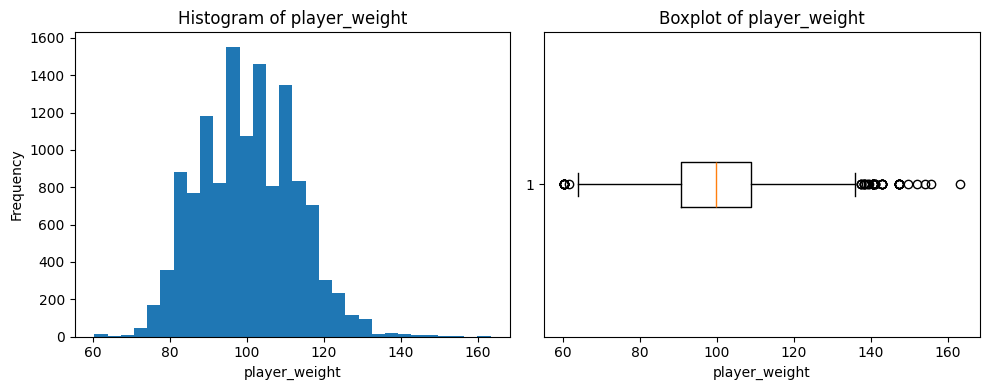

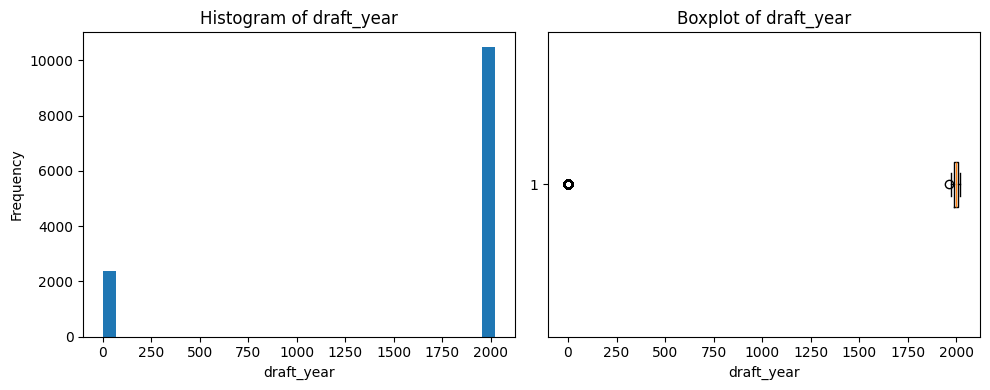

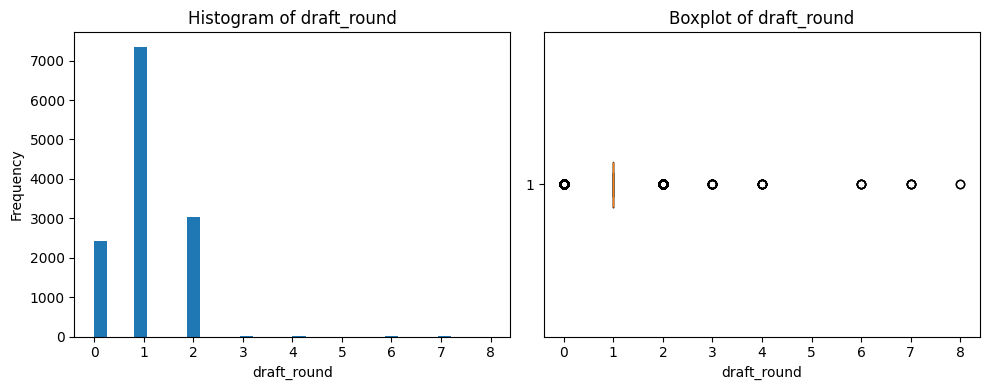

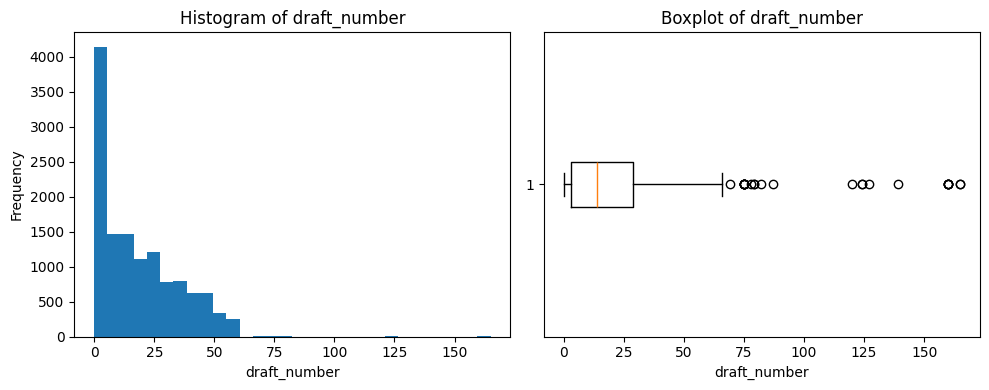

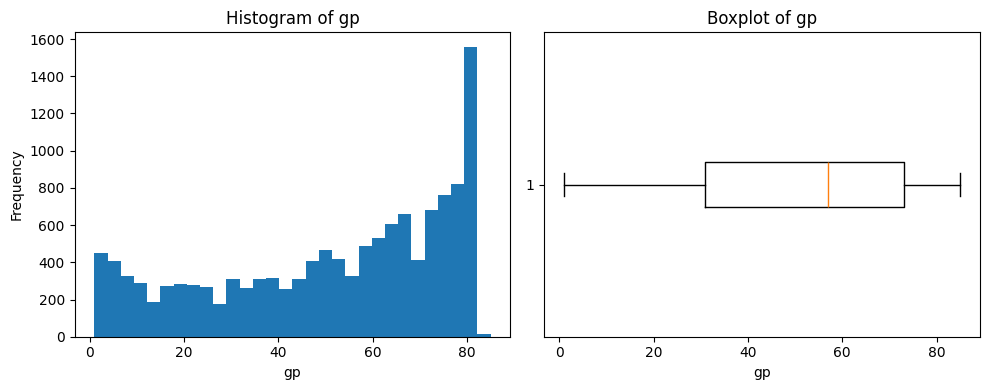

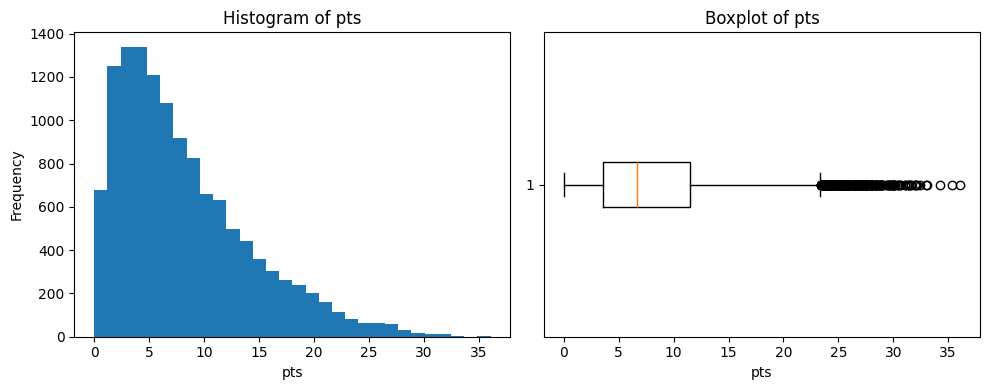

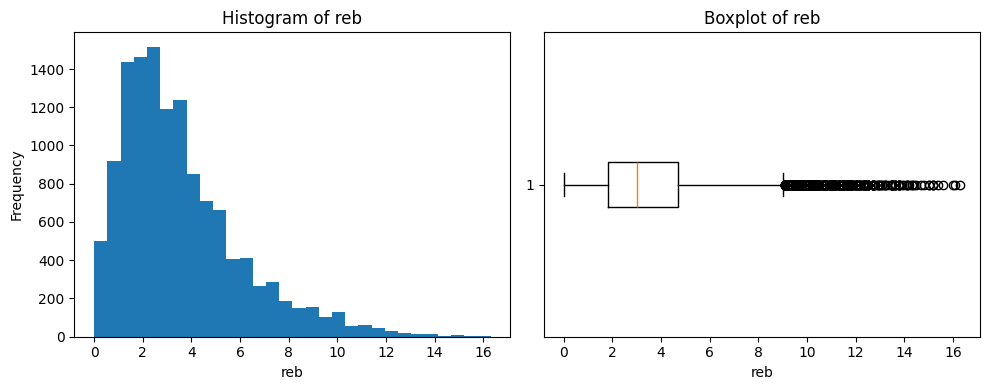

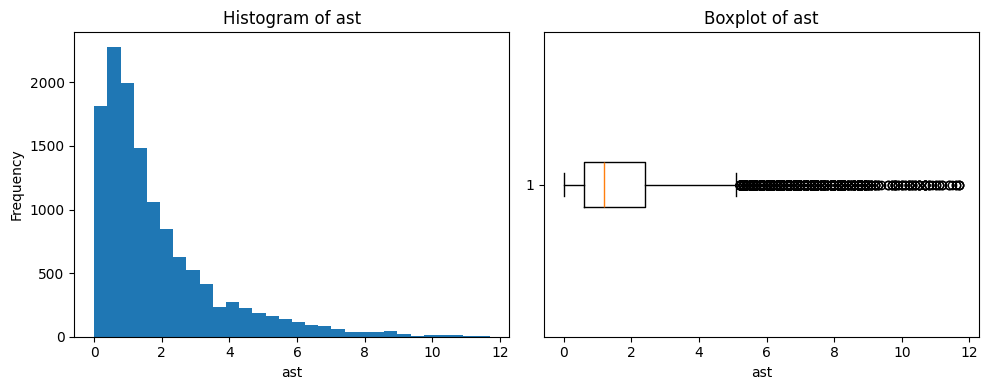

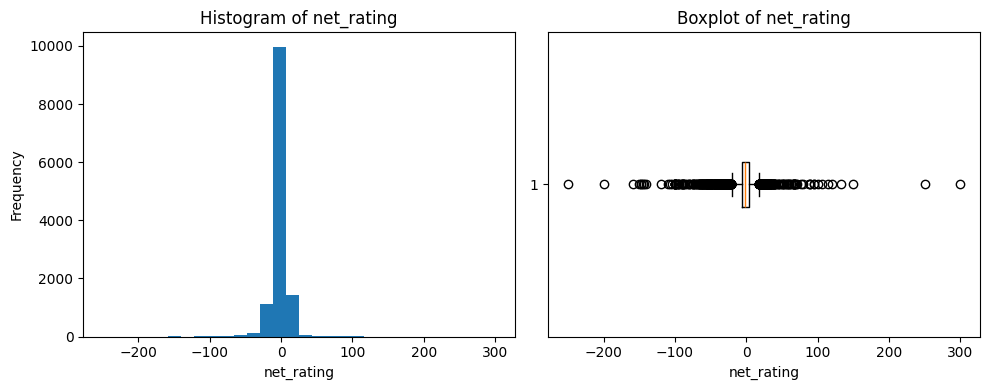

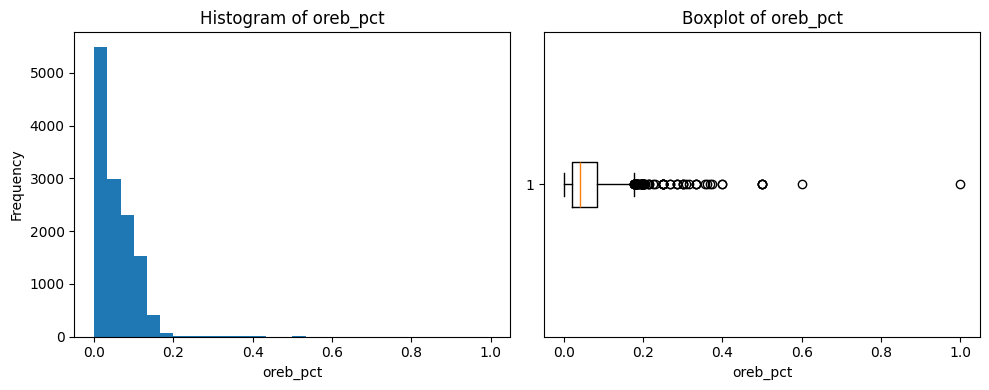

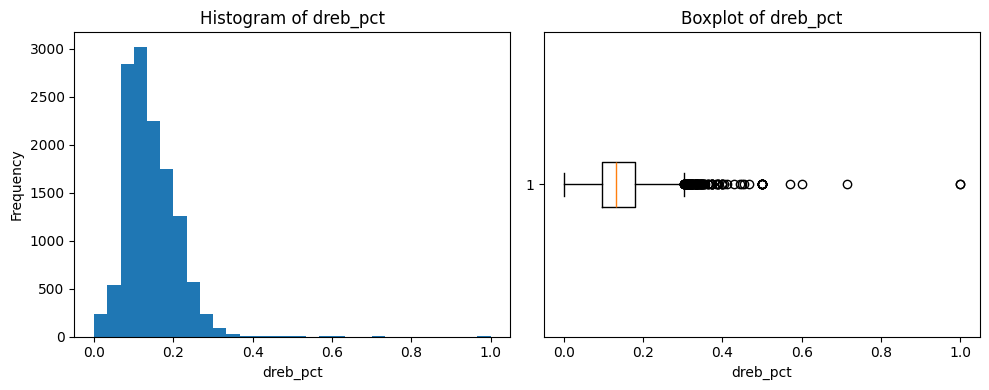

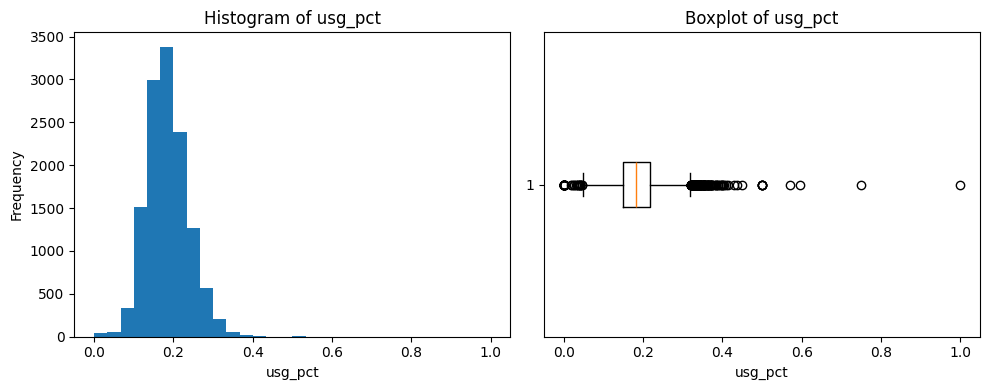

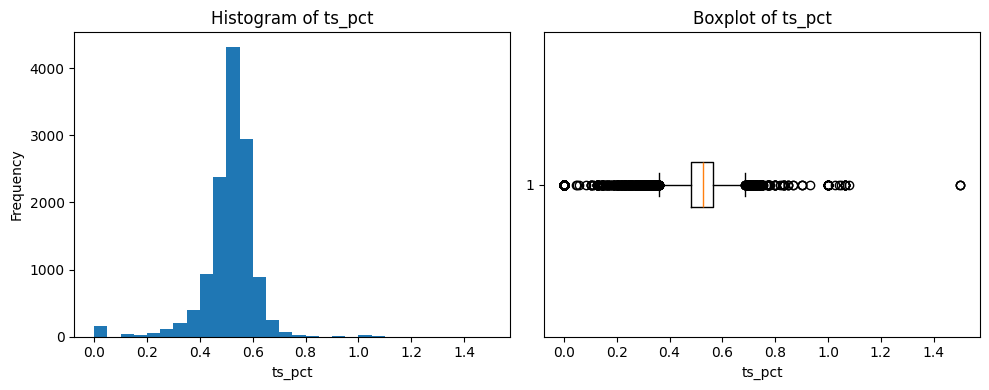

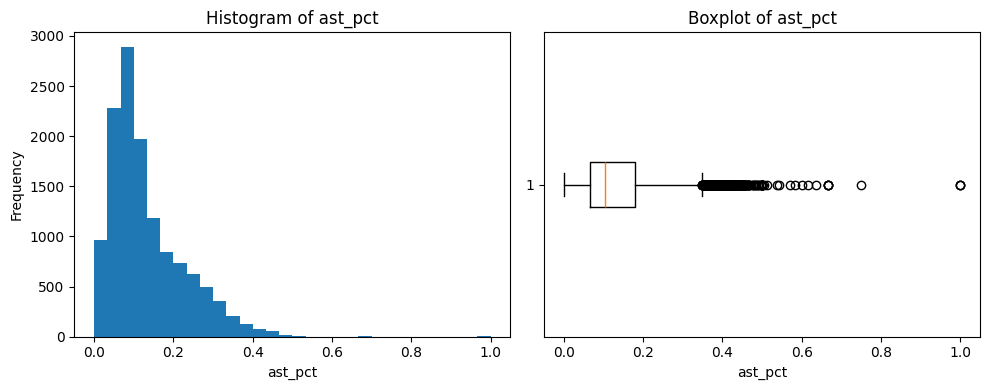

In [27]:
for col in df.columns:
    plt.figure(figsize=(10,4))   
    
    # Histogram
    plt.subplot(1, 2, 1)
    plt.hist(df[col], bins=30)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    
    # Boxplot
    plt.subplot(1, 2, 2)
    plt.boxplot(df[col], vert=False)
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    
    plt.tight_layout()
    plt.show()

In [28]:
X_col = df.drop("pts",axis=1)
Y = df["pts"]

In [29]:
X_col.columns

Index(['age', 'player_height', 'player_weight', 'draft_year', 'draft_round',
       'draft_number', 'gp', 'reb', 'ast', 'net_rating', 'oreb_pct',
       'dreb_pct', 'usg_pct', 'ts_pct', 'ast_pct'],
      dtype='object')

In [30]:
Y.name

'pts'

In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scaler = StandardScaler()  

X = scaler.fit_transform(X_col)  

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=42)  

In [32]:
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


linear_model = LinearRegression()
linear_model.fit(X_train, Y_train)

Y_pred_linear = linear_model.predict(X_test)

mse_linear = mean_squared_error(Y_test, Y_pred_linear)
r_squared_linear = r2_score(Y_test, Y_pred_linear)
mae_linear = mean_absolute_error(Y_test, Y_pred_linear)


sgd_model = SGDRegressor(
    max_iter=1000,
    learning_rate='optimal',
    eta0=0.01,
    random_state=42
)

sgd_model.fit(X_train, Y_train)

Y_pred_sgd = sgd_model.predict(X_test)

mse_sgd = mean_squared_error(Y_test, Y_pred_sgd)
r_squared_sgd = r2_score(Y_test, Y_pred_sgd)
mae_sgd = mean_absolute_error(Y_test, Y_pred_sgd)

In [33]:
comparison_data = {
    'Metric': ['Mean Squared Error (MSE)', 'R-Squared (R²)', 'Mean Absolute Error (MAE)'],
    'Linear Regression': [mse_linear, r_squared_linear, mae_linear],
    'SGDRegressor': [mse_sgd, r_squared_sgd, mae_sgd]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df

,Metric,Linear Regression,SGDRegressor
0,Mean Squared Error (MSE),4.034495,22.080143
1,R-Squared (R²),0.888216,0.388222
2,Mean Absolute Error (MAE),1.368474,3.505188


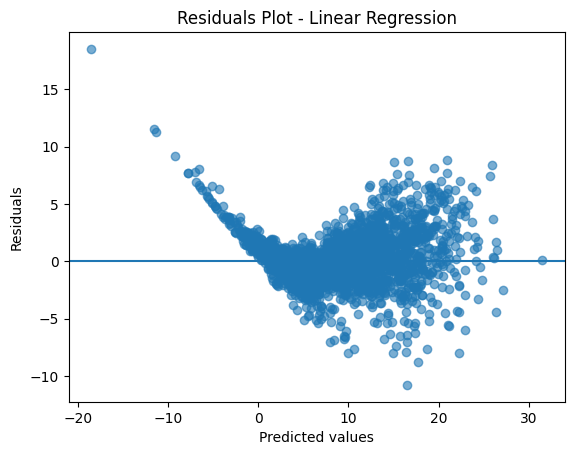

In [34]:
import matplotlib.pyplot as plt


y_pred_linear = linear_model.predict(X_test)


residuals_linear = Y_test - y_pred_linear

plt.figure()
plt.scatter(y_pred_linear, residuals_linear, alpha=0.6)
plt.axhline(y=0)
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.title('Residuals Plot - Linear Regression')
plt.show()

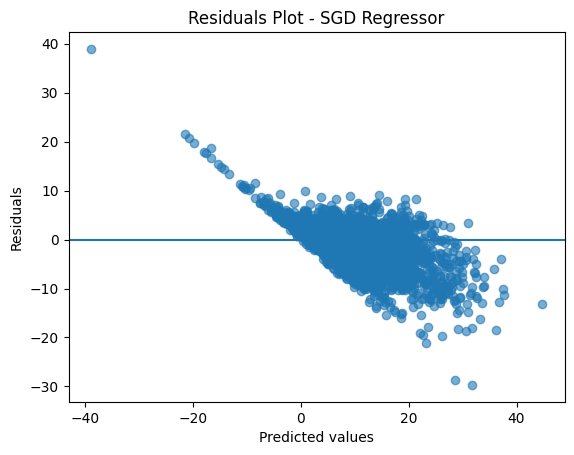

In [35]:
y_pred_sgd = sgd_model.predict(X_test)

residuals_sgd = Y_test - y_pred_sgd

plt.figure()
plt.scatter(y_pred_sgd, residuals_sgd, alpha=0.6)
plt.axhline(y=0)
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.title('Residuals Plot - SGD Regressor')
plt.show()

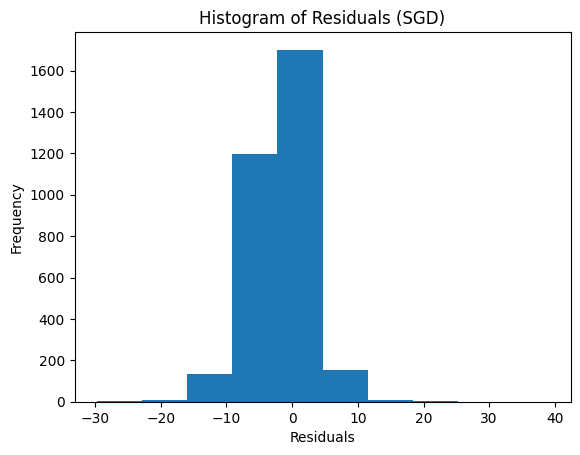

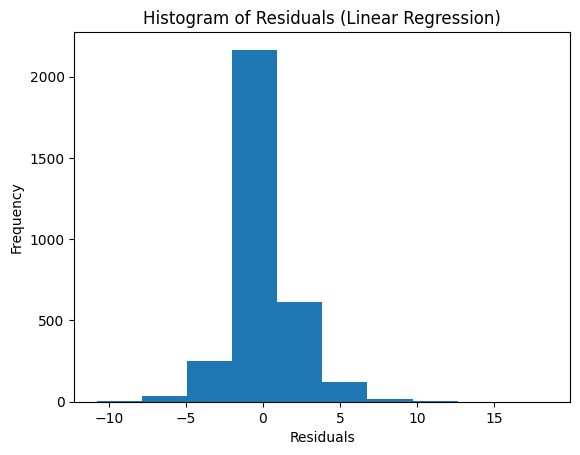

In [36]:
import matplotlib.pyplot as plt

# Histogram for residuals_sgd
plt.figure()
plt.hist(residuals_sgd)
plt.title("Histogram of Residuals (SGD)")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

# Histogram for residuals_linear
plt.figure()
plt.hist(residuals_linear)
plt.title("Histogram of Residuals (Linear Regression)")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

In [37]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

In [38]:
vif_df = pd.DataFrame()
vif_df['Feature'] = X_col.columns
vif_df['VIF'] = [variance_inflation_factor(X_col.values, i) 
                  for i in range(X_col.shape[1])]

In [39]:
vif_df

,Feature,VIF
0,age,41.731597
1,player_height,271.674270
2,player_weight,207.379587
3,draft_year,15.533119
4,draft_round,27.997348
5,draft_number,11.605055
6,gp,8.622470
7,reb,9.839240
8,ast,9.443232
9,net_rating,1.195186


In [40]:
print("-"*100)

----------------------------------------------------------------------------------------------------


In [41]:
feature_names = [
    'age', 'player_height', 'player_weight', 'draft_year', 'draft_round',
    'draft_number', 'gp', 'reb', 'ast', 'net_rating',
    'oreb_pct', 'dreb_pct', 'usg_pct', 'ts_pct', 'ast_pct'
]

X_copied_col = df.drop("pts",axis=1)
Y_copied = df["pts"]

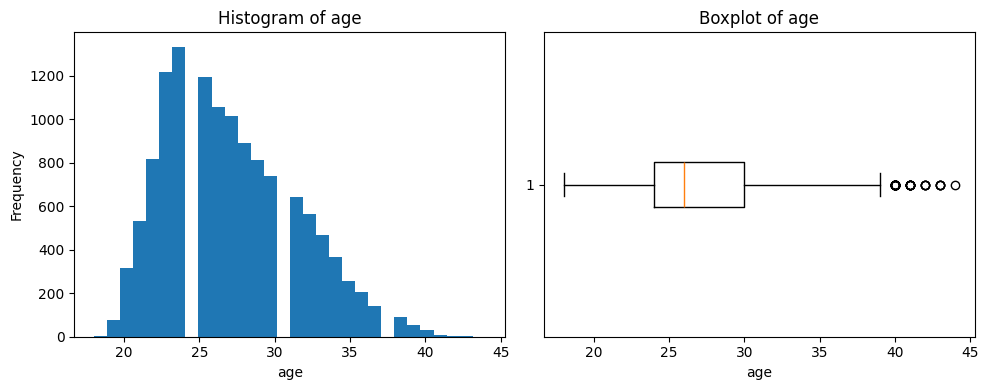

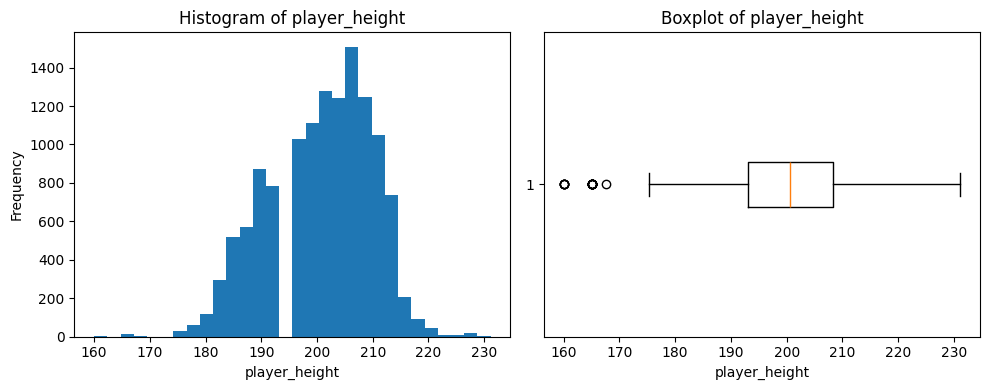

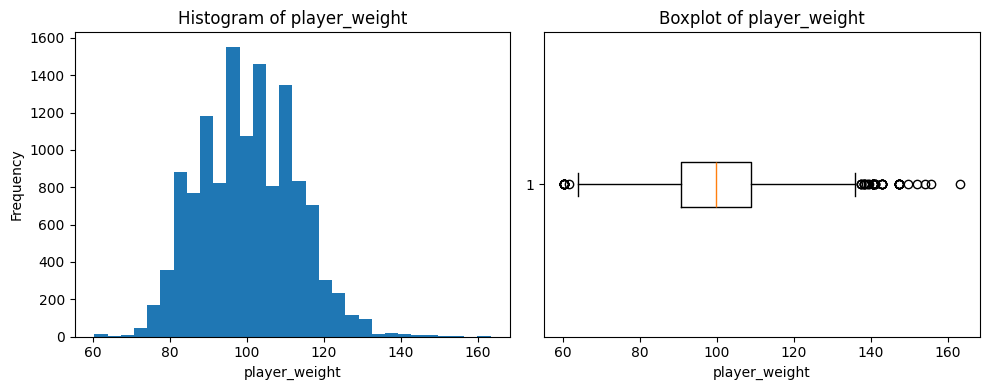

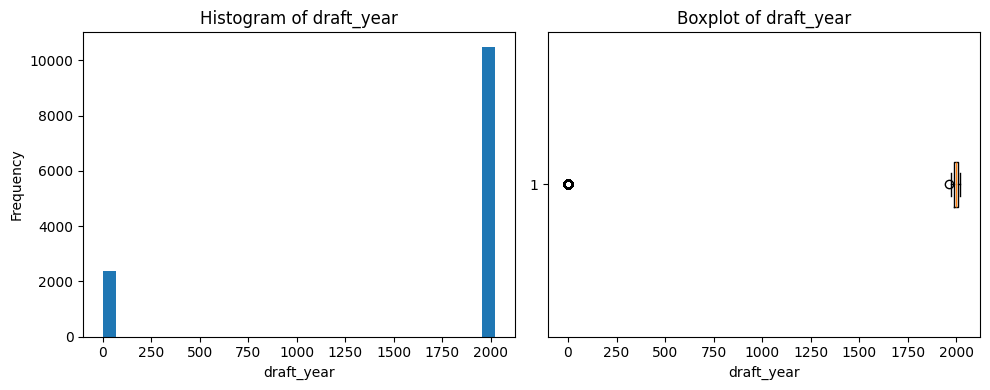

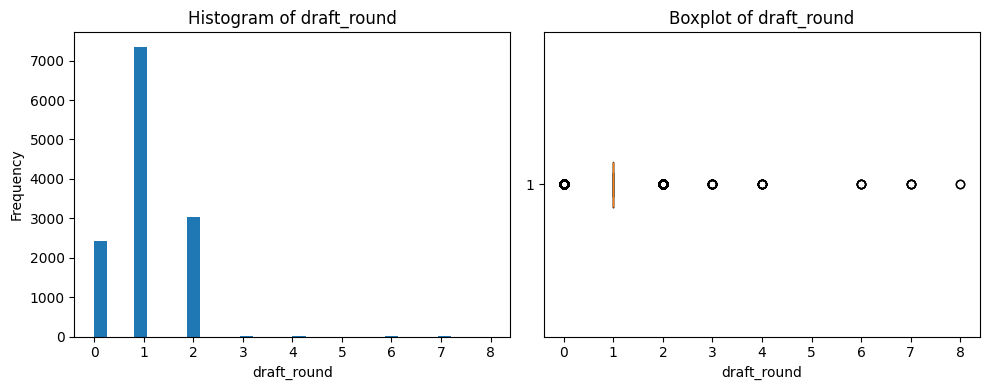

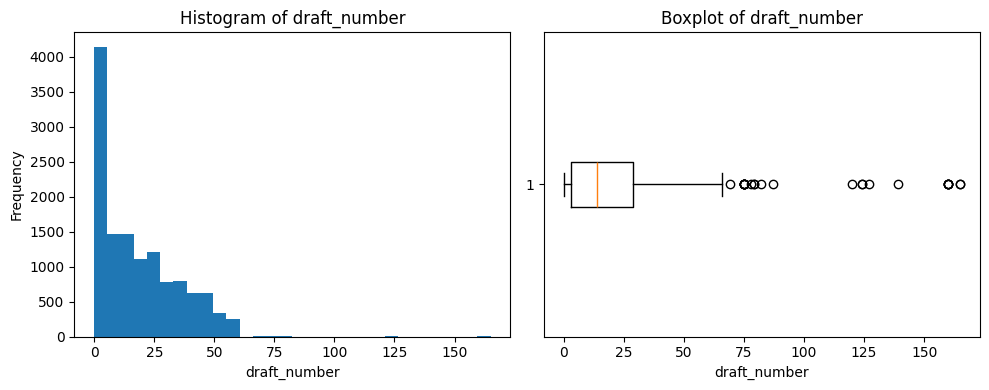

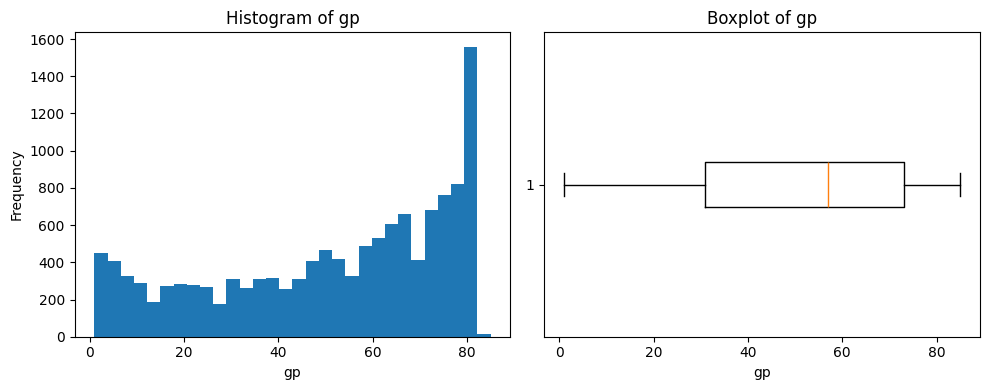

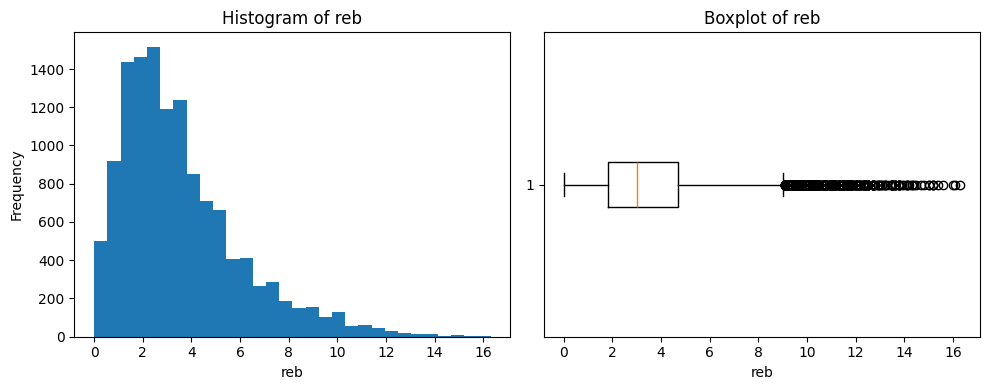

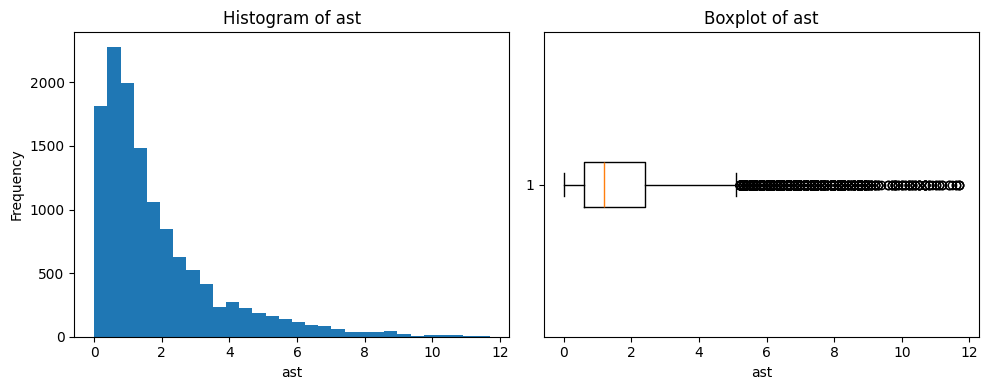

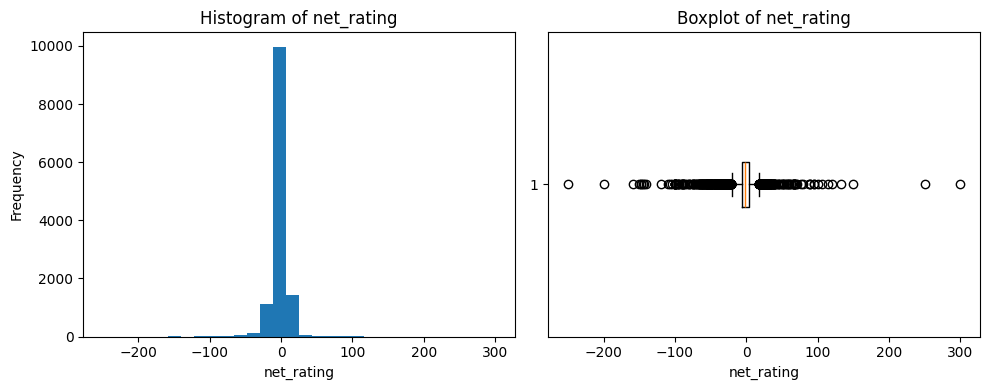

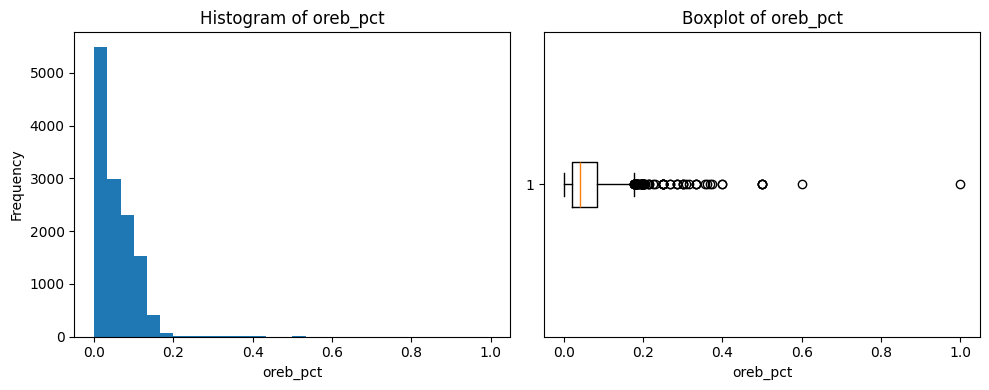

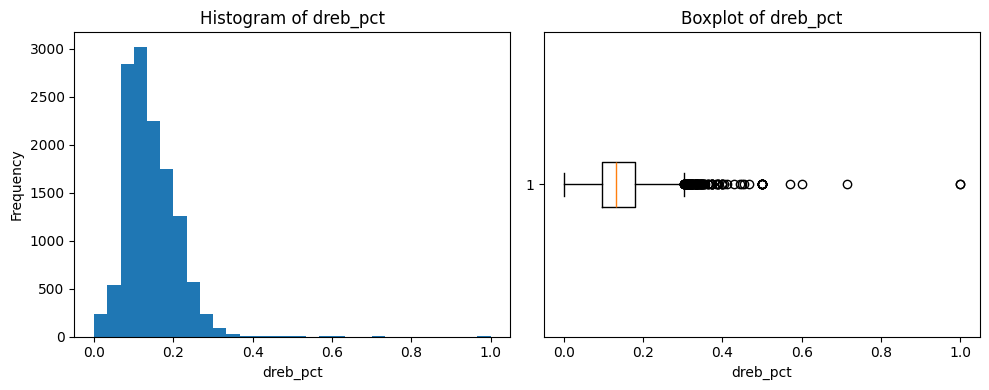

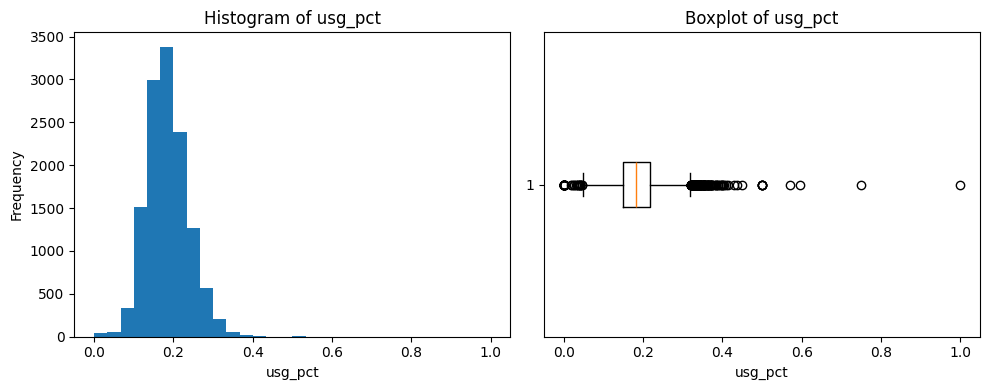

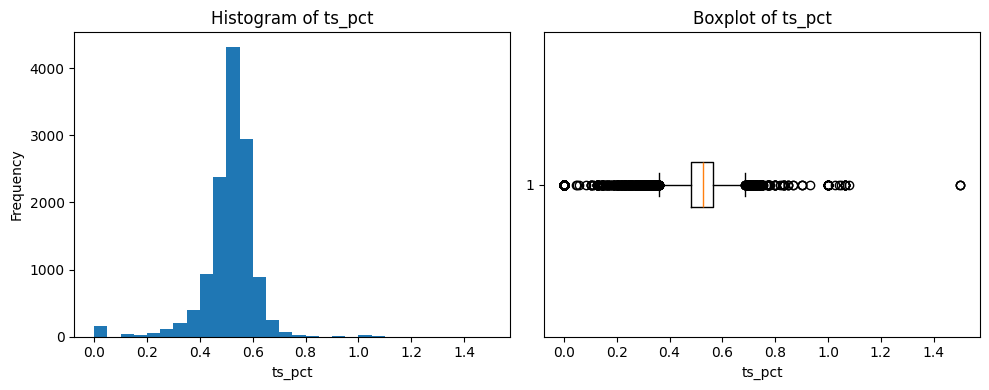

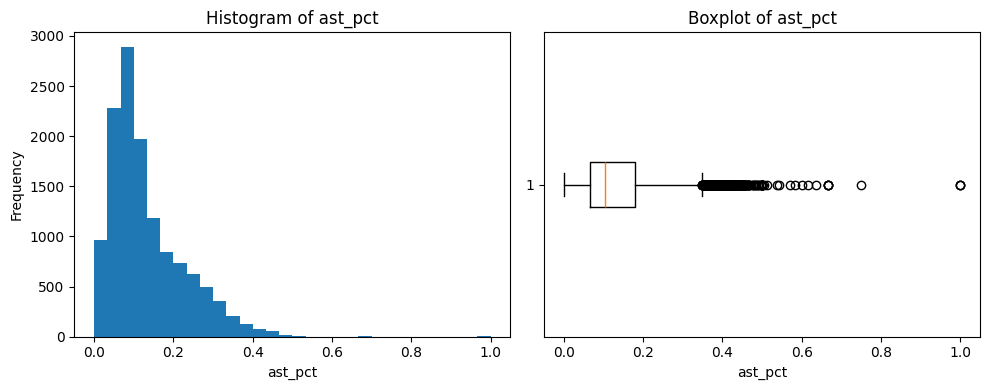

In [42]:
for col in X_copied_col.columns:
    plt.figure(figsize=(10,4))   
    
    # Histogram
    plt.subplot(1, 2, 1)
    plt.hist(X_copied_col[col], bins=30)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    
    # Boxplot
    plt.subplot(1, 2, 2)
    plt.boxplot(X_copied_col[col], vert=False)
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    
    plt.tight_layout()
    plt.show()

In [43]:
import numpy as np

log_cols = [
 'draft_number',
    'gp',
    'reb',
    'ast',
    'oreb_pct',
    'dreb_pct',
    'usg_pct',
    'ast_pct',
     ]

for col in log_cols:
    X_copied_col[col] = np.log1p(X_copied_col[col])

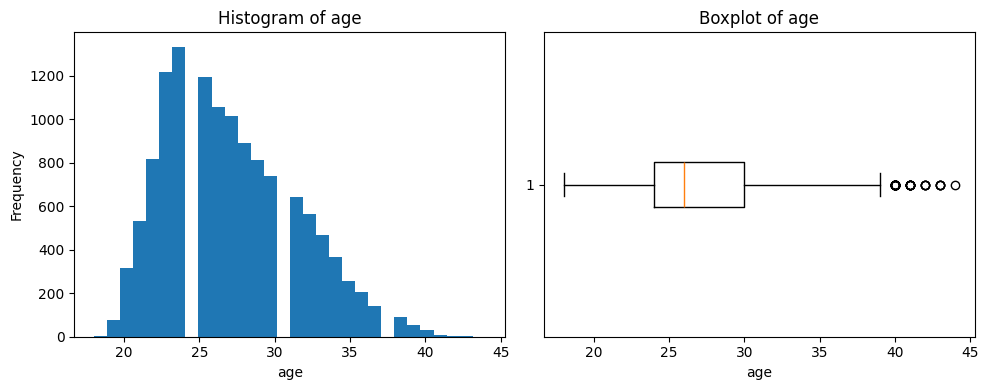

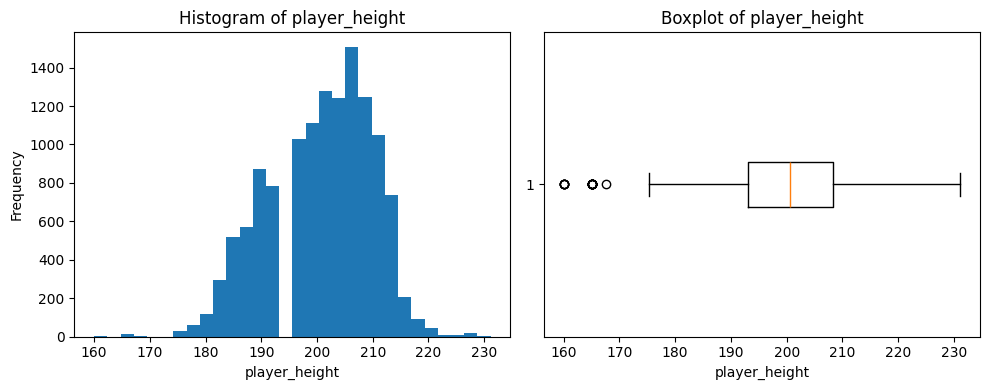

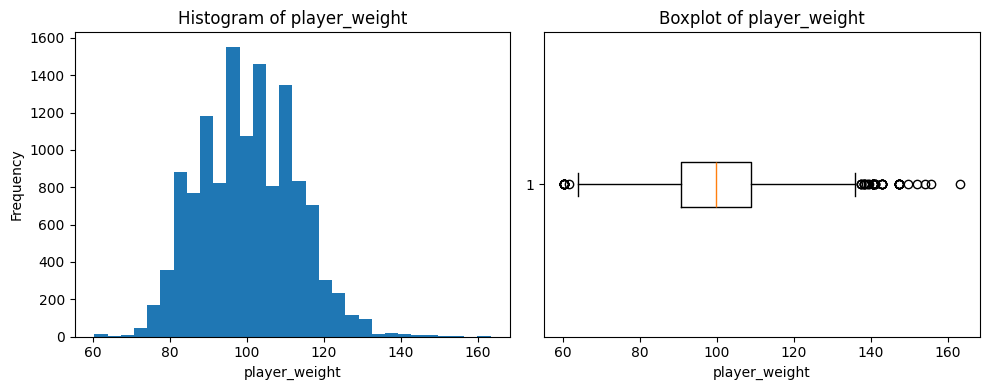

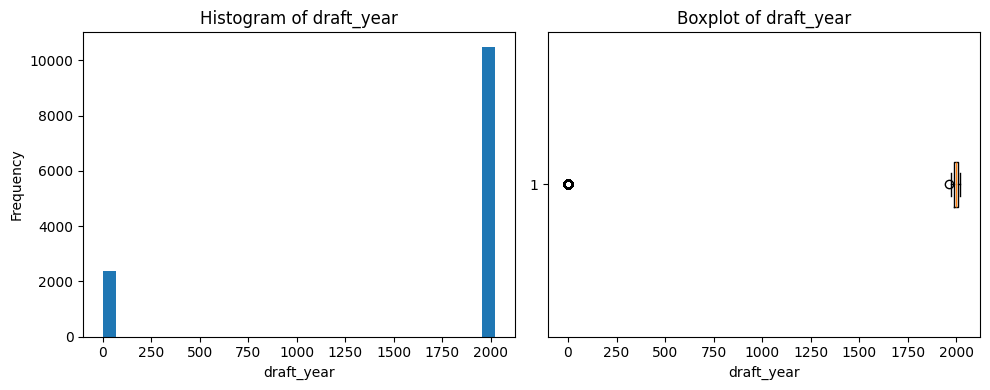

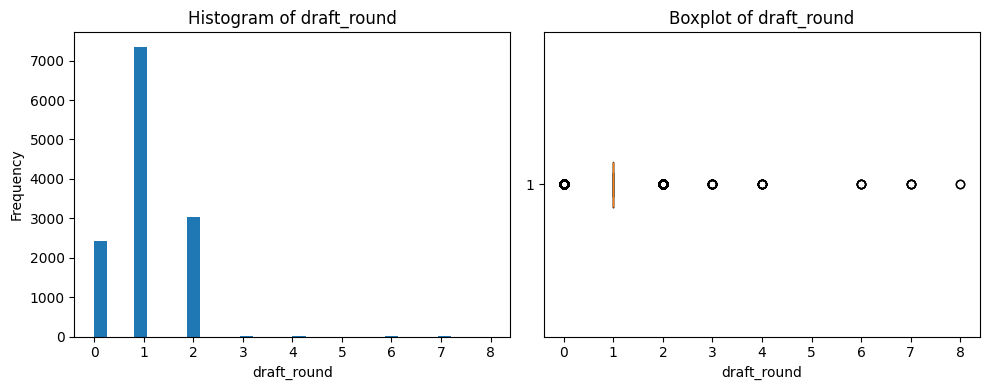

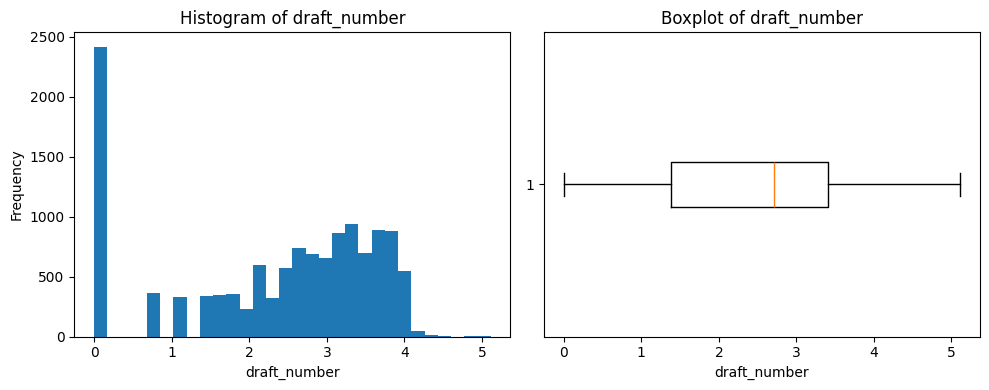

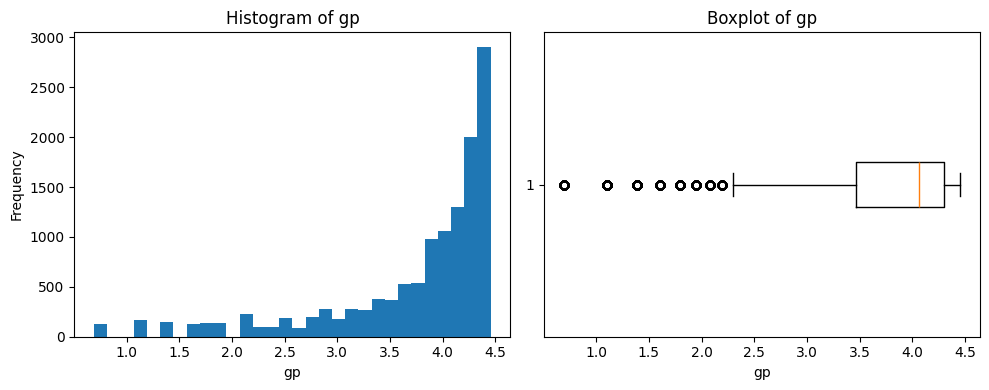

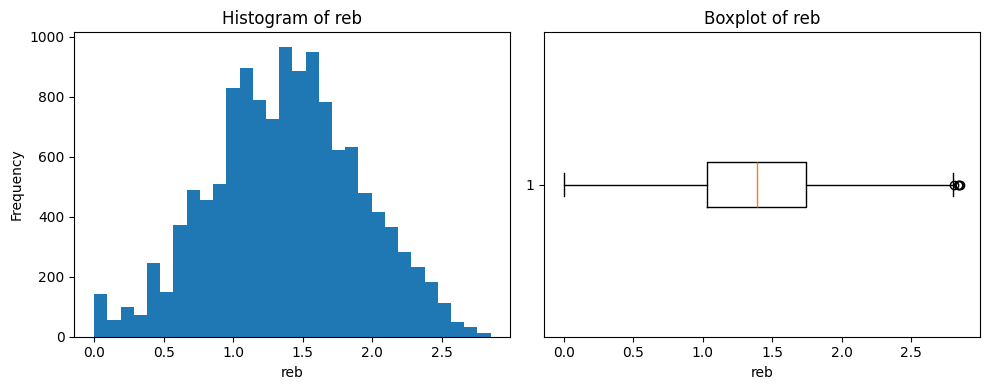

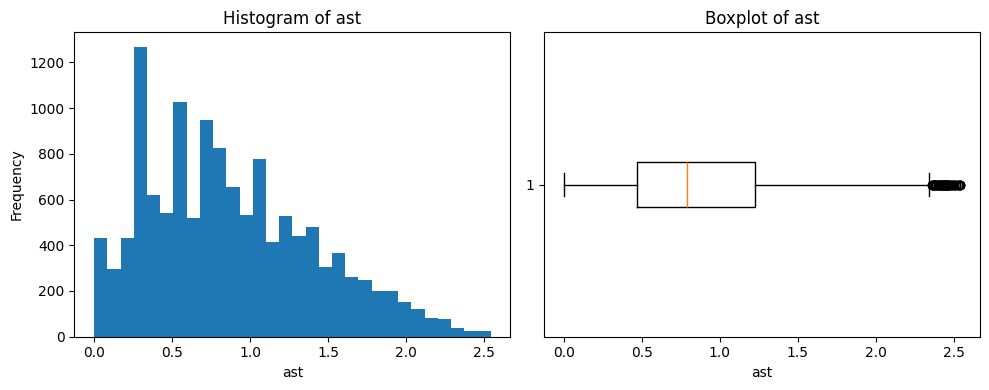

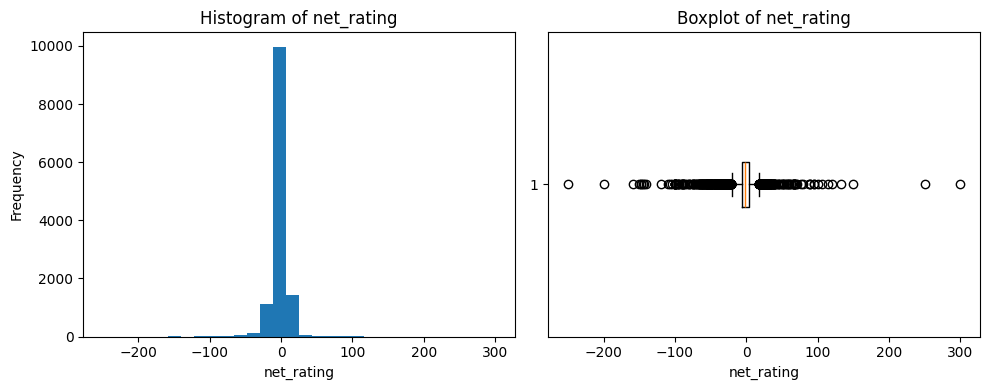

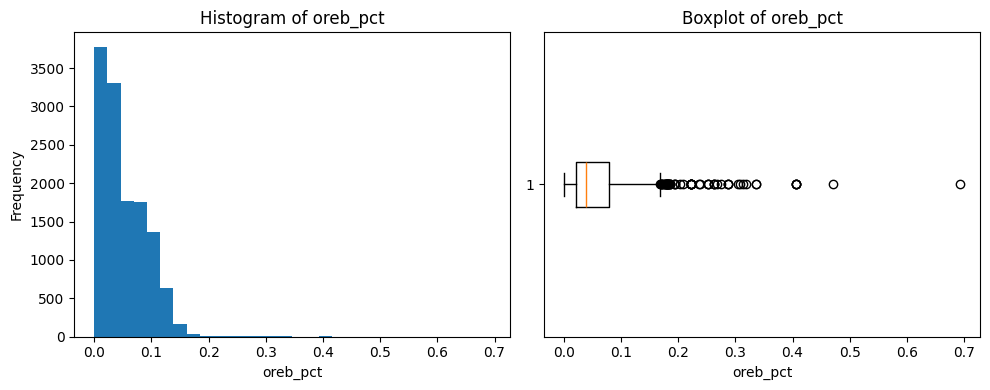

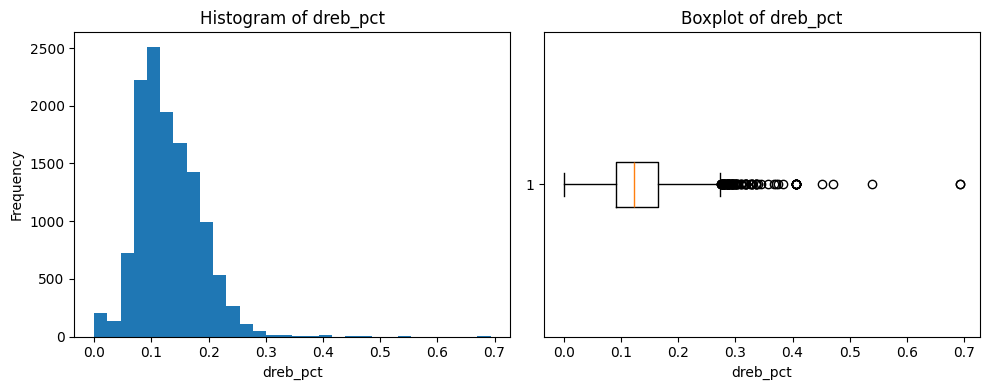

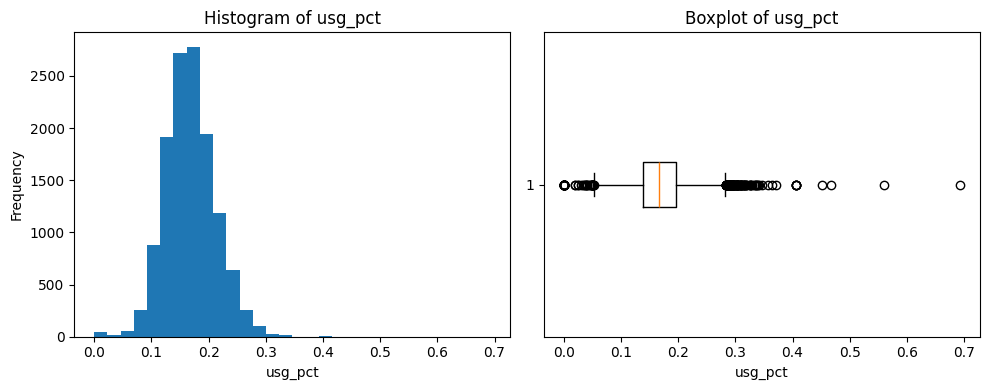

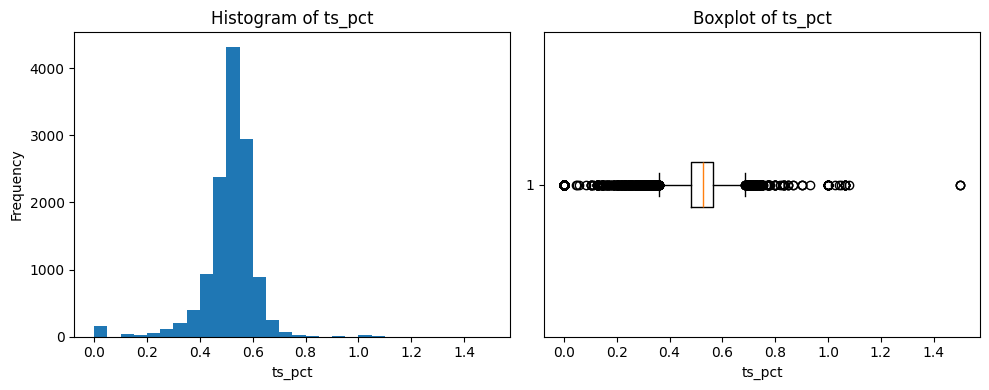

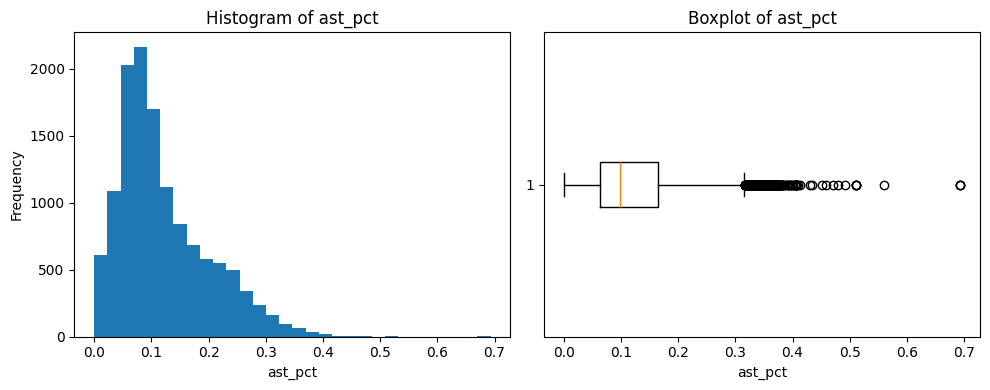

In [44]:
for col in X_copied_col.columns:
    plt.figure(figsize=(10,4))   
    
    # Histogram
    plt.subplot(1, 2, 1)
    plt.hist(X_copied_col[col], bins=30)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    
    # Boxplot
    plt.subplot(1, 2, 2)
    plt.boxplot(X_copied_col[col], vert=False)
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    
    plt.tight_layout()
    plt.show()

In [45]:
X_copied = scaler.fit_transform(X_copied_col)

In [46]:
X_train, X_test, Y_train, Y_test = train_test_split(X_copied, Y_copied, test_size=0.25, random_state=42) 

In [47]:
linear_model = LinearRegression()
linear_model.fit(X_train, Y_train)

Y_pred_linear = linear_model.predict(X_test)

mse_linear = mean_squared_error(Y_test, Y_pred_linear)
r_squared_linear = r2_score(Y_test, Y_pred_linear)
mae_linear = mean_absolute_error(Y_test, Y_pred_linear)


sgd_model = SGDRegressor(
    max_iter=1000,
    learning_rate='optimal',
    eta0=0.01,
    random_state=42
)

sgd_model.fit(X_train, Y_train)

Y_pred_sgd = sgd_model.predict(X_test)

mse_sgd = mean_squared_error(Y_test, Y_pred_sgd)
r_squared_sgd = r2_score(Y_test, Y_pred_sgd)
mae_sgd = mean_absolute_error(Y_test, Y_pred_sgd)


In [48]:
comparison_data = {
    'Metric': ['Mean Squared Error (MSE)', 'R-Squared (R²)', 'Mean Absolute Error (MAE)'],
    'Linear Regression': [mse_linear, r_squared_linear, mae_linear],
    'SGDRegressor': [mse_sgd, r_squared_sgd, mae_sgd]
}

comparison_df_after_log = pd.DataFrame(comparison_data)


In [49]:
comparison_df_after_log

,Metric,Linear Regression,SGDRegressor
0,Mean Squared Error (MSE),4.229317,5.266776
1,R-Squared (R²),0.882818,0.854073
2,Mean Absolute Error (MAE),1.476669,1.672680


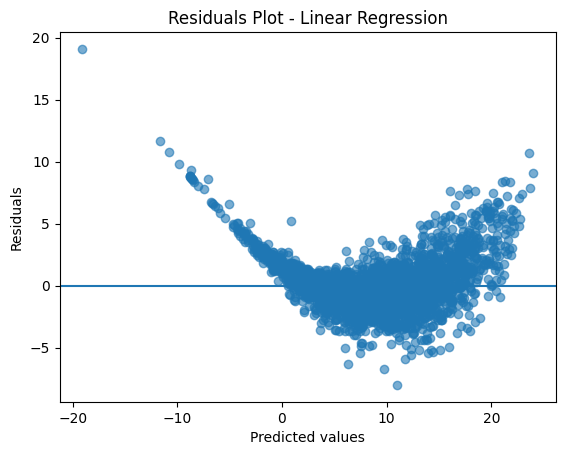

In [50]:
import matplotlib.pyplot as plt


y_pred_linear = linear_model.predict(X_test)


residuals_linear = Y_test - y_pred_linear

plt.figure()
plt.scatter(y_pred_linear, residuals_linear, alpha=0.6)
plt.axhline(y=0)
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.title('Residuals Plot - Linear Regression')
plt.show()

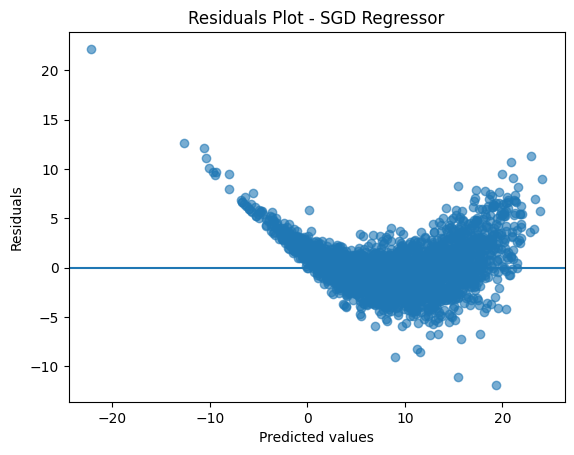

In [51]:
y_pred_sgd = sgd_model.predict(X_test)

residuals_sgd = Y_test - y_pred_sgd

plt.figure()
plt.scatter(y_pred_sgd, residuals_sgd, alpha=0.6)
plt.axhline(y=0)
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.title('Residuals Plot - SGD Regressor')
plt.show()

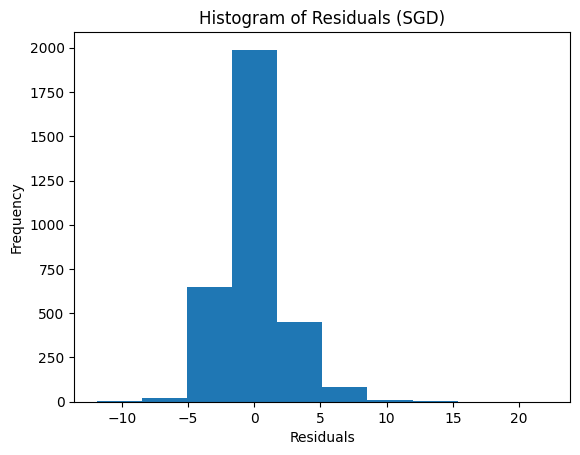

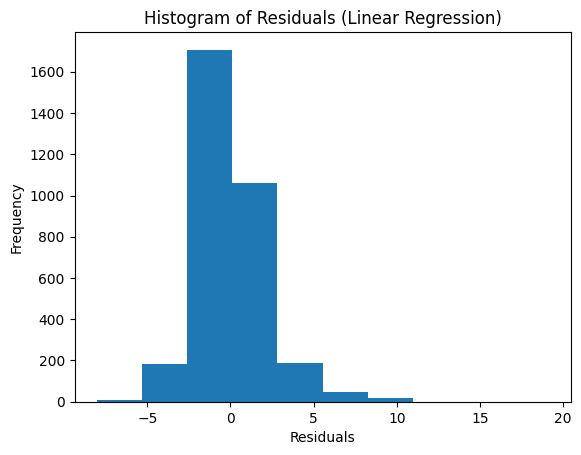

In [52]:
import matplotlib.pyplot as plt

# Histogram for residuals_sgd
plt.figure()
plt.hist(residuals_sgd)
plt.title("Histogram of Residuals (SGD)")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

# Histogram for residuals_linear
plt.figure()
plt.hist(residuals_linear)
plt.title("Histogram of Residuals (Linear Regression)")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

In [53]:
vif_df = pd.DataFrame()
vif_df['Feature'] = X_copied_col.columns
vif_df['VIF'] = [variance_inflation_factor(X_copied_col.values, i) 
                  for i in range(X_copied_col.shape[1])]

In [54]:
vif_df

,Feature,VIF
0,age,42.223915
1,player_height,277.496751
2,player_weight,209.829548
3,draft_year,20.330927
4,draft_round,13.727738
5,draft_number,22.148046
6,gp,37.855409
7,reb,64.905662
8,ast,48.681118
9,net_rating,1.197450


In [55]:
print(comparison_df)
print("-"*100)
print(comparison_df_after_log)

                      Metric  Linear Regression  SGDRegressor
0   Mean Squared Error (MSE)           4.034495     22.080143
1             R-Squared (R²)           0.888216      0.388222
2  Mean Absolute Error (MAE)           1.368474      3.505188
----------------------------------------------------------------------------------------------------
                      Metric  Linear Regression  SGDRegressor
0   Mean Squared Error (MSE)           4.229317      5.266776
1             R-Squared (R²)           0.882818      0.854073
2  Mean Absolute Error (MAE)           1.476669      1.672680


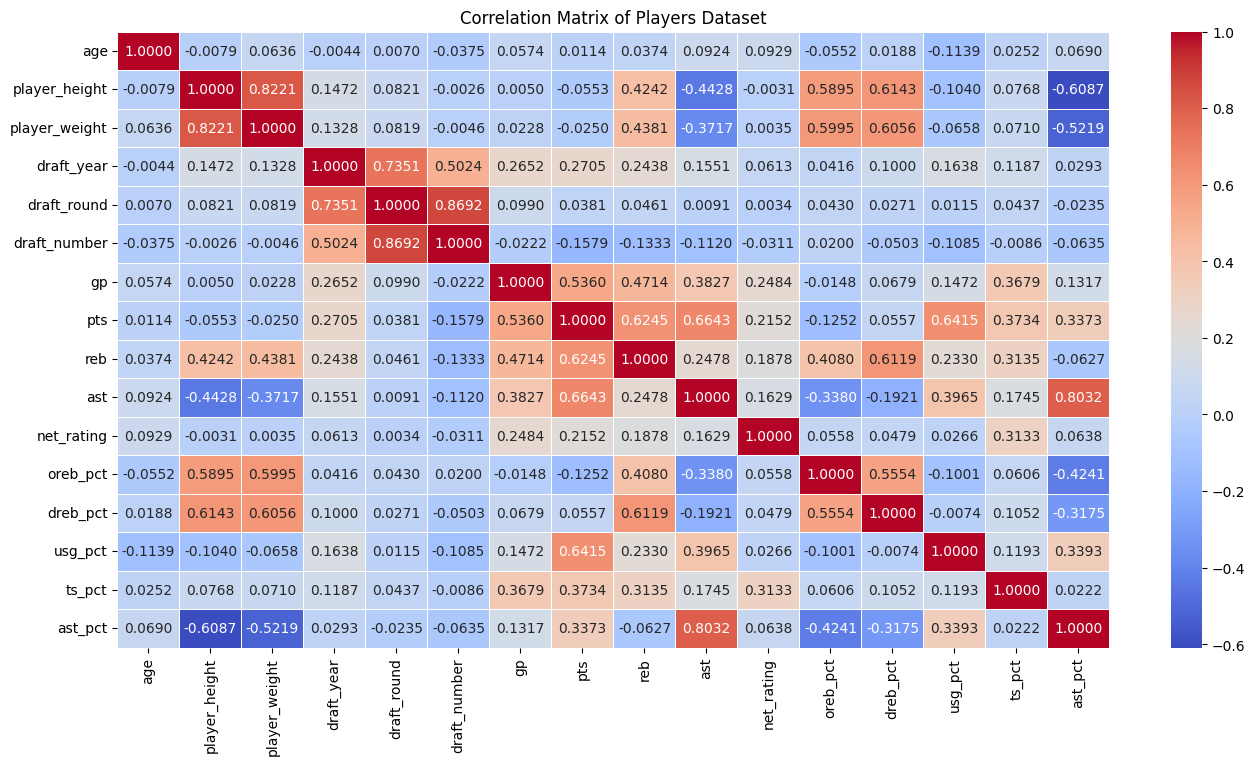

In [56]:
correlation_matrix = df.select_dtypes(exclude=['object']).corr()
plt.figure(figsize=(16, 8))  
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.4f', linewidths=0.5)  
plt.title('Correlation Matrix of Players Dataset') 
plt.show()  

In [57]:
only_linear_col = df[['gp', 'reb', 'ast', 'usg_pct']]
y = df['pts']

In [58]:
only_linear_scaled = scaler.fit_transform(only_linear_col)

In [59]:
X_train, X_test, Y_train, Y_test = train_test_split(only_linear_scaled , y, test_size=0.25, random_state=42) 

In [60]:
linear_model = LinearRegression()
linear_model.fit(X_train, Y_train)

Y_pred_linear = linear_model.predict(X_test)

mse_linear = mean_squared_error(Y_test, Y_pred_linear)
r_squared_linear = r2_score(Y_test, Y_pred_linear)
mae_linear = mean_absolute_error(Y_test, Y_pred_linear)


sgd_model = SGDRegressor(
    max_iter=1000,
    learning_rate='optimal',
    eta0=0.01,
    random_state=42
)

sgd_model.fit(X_train, Y_train)

Y_pred_sgd = sgd_model.predict(X_test)

mse_sgd = mean_squared_error(Y_test, Y_pred_sgd)
r_squared_sgd = r2_score(Y_test, Y_pred_sgd)
mae_sgd = mean_absolute_error(Y_test, Y_pred_sgd)

In [61]:
comparison_data = {
    'Metric': ['Mean Squared Error (MSE)', 'R-Squared (R²)', 'Mean Absolute Error (MAE)'],
    'Linear Regression': [mse_linear, r_squared_linear, mae_linear],
    'SGDRegressor': [mse_sgd, r_squared_sgd, mae_sgd]
}

comparison = pd.DataFrame(comparison_data)

In [62]:
print(comparison_df)
print('-'*100)
print(comparison_df_after_log)
print('-'*100)
print(comparison)


                      Metric  Linear Regression  SGDRegressor
0   Mean Squared Error (MSE)           4.034495     22.080143
1             R-Squared (R²)           0.888216      0.388222
2  Mean Absolute Error (MAE)           1.368474      3.505188
----------------------------------------------------------------------------------------------------
                      Metric  Linear Regression  SGDRegressor
0   Mean Squared Error (MSE)           4.229317      5.266776
1             R-Squared (R²)           0.882818      0.854073
2  Mean Absolute Error (MAE)           1.476669      1.672680
----------------------------------------------------------------------------------------------------
                      Metric  Linear Regression  SGDRegressor
0   Mean Squared Error (MSE)           6.745611      7.366700
1             R-Squared (R²)           0.813098      0.795890
2  Mean Absolute Error (MAE)           1.955212      2.036735


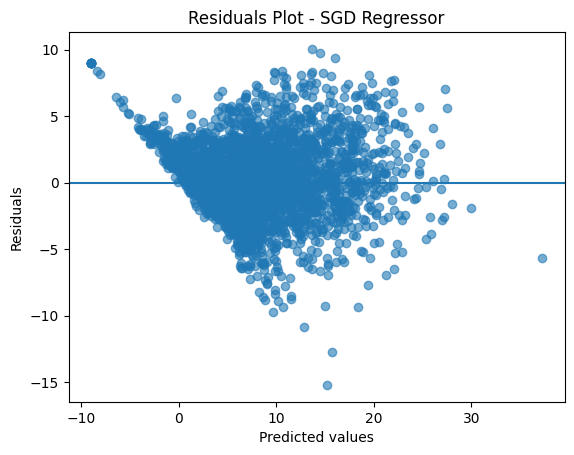

In [63]:
y_pred_sgd = sgd_model.predict(X_test)

residuals_sgd = Y_test - y_pred_sgd

plt.figure()
plt.scatter(y_pred_sgd, residuals_sgd, alpha=0.6)
plt.axhline(y=0)
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.title('Residuals Plot - SGD Regressor')
plt.show()

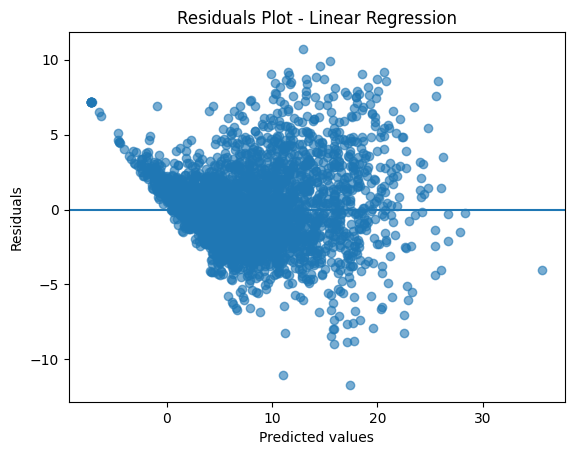

In [64]:
import matplotlib.pyplot as plt


y_pred_linear = linear_model.predict(X_test)


residuals_linear = Y_test - y_pred_linear

plt.figure()
plt.scatter(y_pred_linear, residuals_linear, alpha=0.6)
plt.axhline(y=0)
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.title('Residuals Plot - Linear Regression')
plt.show()

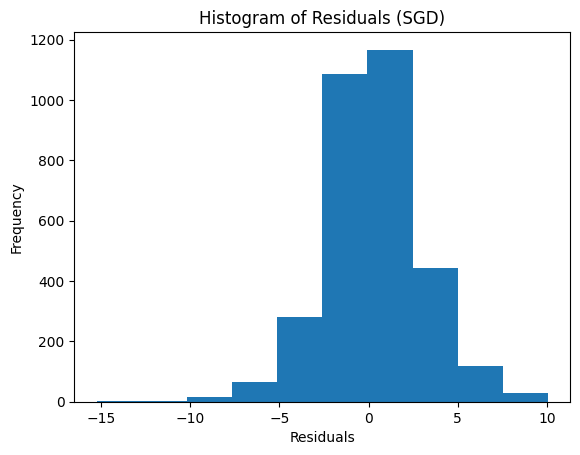

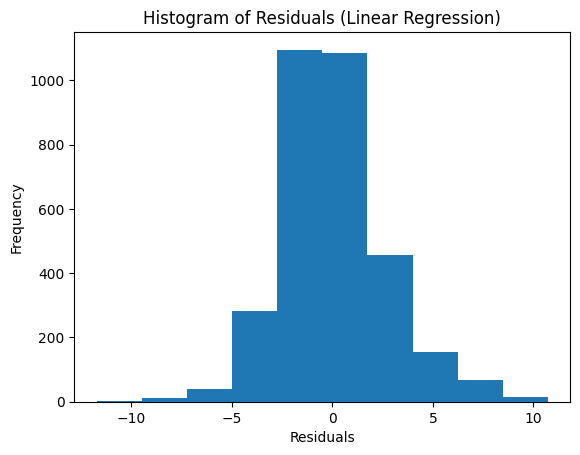

In [65]:
import matplotlib.pyplot as plt

# Histogram for residuals_sgd
plt.figure()
plt.hist(residuals_sgd)
plt.title("Histogram of Residuals (SGD)")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

# Histogram for residuals_linear
plt.figure()
plt.hist(residuals_linear)
plt.title("Histogram of Residuals (Linear Regression)")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

In [66]:
only_linear_col

,gp,reb,ast,usg_pct
0,64,1.5,2.4,0.169
1,4,1.3,0.3,0.174
2,41,6.4,1.9,0.175
3,64,2.8,1.7,0.206
4,52,1.7,0.3,0.195
...,...,...,...,...
12839,66,10.2,4.2,0.370
12840,19,0.9,0.6,0.102
12841,71,6.5,1.2,0.168
12842,52,4.7,0.5,0.074


In [67]:
vif_df = pd.DataFrame()
vif_df['Feature'] = only_linear_col.columns
vif_df['VIF'] = [variance_inflation_factor(only_linear_col.values, i)
                 for i in range(only_linear_col.shape[1])]

In [68]:
vif_df

,Feature,VIF
0,gp,6.150763
1,reb,4.081336
2,ast,2.586471
3,usg_pct,5.305879


In [69]:
y_intercept = sgd_model.intercept_.round(4)
coefficients = sgd_model.coef_
coef_df = pd.DataFrame({
    'Feature': only_linear_col.columns,
    'Coefficient': coefficients
})

print("y_intercept =", y_intercept)
print(coef_df)

y_intercept = [7.9454]
   Feature  Coefficient
0       gp     0.482951
1      reb     2.096112
2      ast     1.976406
3  usg_pct     3.181147


In [70]:
print("SGD Model equation: y =", y_intercept, "+", " + ".join(f"{coef:.4f}*{feat}" for coef, feat in zip(coefficients, only_linear_col.columns)))

SGD Model equation: y = [7.9454] + 0.4830*gp + 2.0961*reb + 1.9764*ast + 3.1811*usg_pct


In [71]:
y_intercept = linear_model.intercept_.round(4)
coefficients = linear_model.coef_
coef_df = pd.DataFrame({
    'Feature': only_linear_col.columns,
    'Coefficient': coefficients
})

print("y_intercept =", y_intercept)
print(coef_df)

y_intercept = 8.1969
   Feature  Coefficient
0       gp     1.041182
1      reb     2.209211
2      ast     2.143097
3  usg_pct     2.307814


In [72]:
print("Linear Regression Model equation: y =", y_intercept, "+", " + ".join(f"{coef:.4f}*{feat}" for coef, feat in zip(coefficients, only_linear_col.columns)))

Linear Regression Model equation: y = 8.1969 + 1.0412*gp + 2.2092*reb + 2.1431*ast + 2.3078*usg_pct
